In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_dir = '../data/Snake Images'
img_size = (150, 150)   # smaller than original 400x400 — keeps CPU training fast
batch_size = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2   # 20% of train/ held out for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{data_dir}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    f'{data_dir}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    f'{data_dir}/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print(train_gen.class_indices)

Found 1420 images belonging to 2 classes.
Found 355 images belonging to 2 classes.
Found 269 images belonging to 2 classes.
{'Non Venomous': 0, 'Venomous': 1}


In [4]:
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.2412587412587412, 1: 0.8372641509433962}


In [5]:
baseline_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 128)     

In [6]:
history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


45/45 [==============================] - 65s 1s/step - loss: 0.7055 - accuracy: 0.5620 - val_loss: 0.6937 - val_accuracy: 0.4000
Epoch 2/10
45/45 [==============================] - 56s 1s/step - loss: 0.6933 - accuracy: 0.5113 - val_loss: 0.6833 - val_accuracy: 0.6282
Epoch 3/10
45/45 [==============================] - 55s 1s/step - loss: 0.6891 - accuracy: 0.5190 - val_loss: 0.6839 - val_accuracy: 0.3915
Epoch 4/10
45/45 [==============================] - 56s 1s/step - loss: 0.6881 - accuracy: 0.5577 - val_loss: 0.6769 - val_accuracy: 0.6000
Epoch 5/10
45/45 [==============================] - 57s 1s/step - loss: 0.6837 - accuracy: 0.6042 - val_loss: 0.6690 - val_accuracy: 0.6254
Epoch 6/10
45/45 [==============================] - 66s 1s/step - loss: 0.6789 - accuracy: 0.5880 - val_loss: 0.6652 - val_accuracy: 0.6113
Epoch 7/10
45/45 [==============================] - 55s 1s/step - loss: 0.6776 - accuracy: 0.6014 - val_loss: 0.6901 - val_accuracy: 0.5915
Epoch 8/10
45/45 [

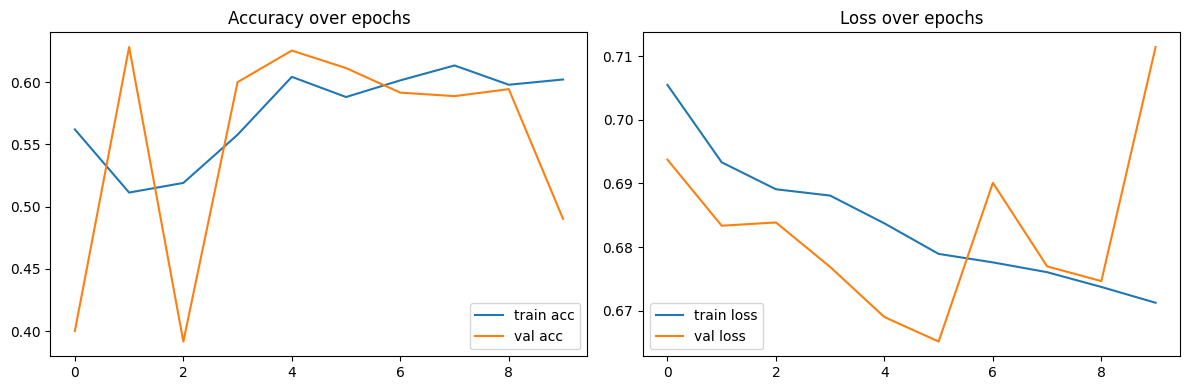

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()

plt.tight_layout()
plt.savefig('../notebooks/baseline_training_curves.png', dpi=150)
plt.show()

In [8]:
import os
os.makedirs('../models', exist_ok=True)
baseline_model.save('../models/baseline_cnn.h5')

C:\Users\inshaaf\anaconda3\envs\snake-classifier\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
